## import libraries and Data

In [388]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , LabelEncoder

from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier 

from sklearn.metrics import confusion_matrix , classification_report ,accuracy_score

In [389]:
df = pd.read_csv('Titanic-Dataset.csv')

## Explor Data

In [390]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [391]:
df.sample()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
515,516,0,1,"Walker, Mr. William Anderson",male,47.0,0,0,36967,34.0208,D46,S


In [392]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [393]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [394]:
df.describe().round()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.0,891.0,891.0,714.0,891.0,891.0,891.0
mean,446.0,0.0,2.0,30.0,1.0,0.0,32.0
std,257.0,0.0,1.0,15.0,1.0,1.0,50.0
min,1.0,0.0,1.0,0.0,0.0,0.0,0.0
25%,224.0,0.0,2.0,20.0,0.0,0.0,8.0
50%,446.0,0.0,3.0,28.0,0.0,0.0,14.0
75%,668.0,1.0,3.0,38.0,1.0,0.0,31.0
max,891.0,1.0,3.0,80.0,8.0,6.0,512.0


In [395]:
df.duplicated().sum()

np.int64(0)

In [396]:
na = df.isna().sum()
na[na>0]

Age         177
Cabin       687
Embarked      2
dtype: int64

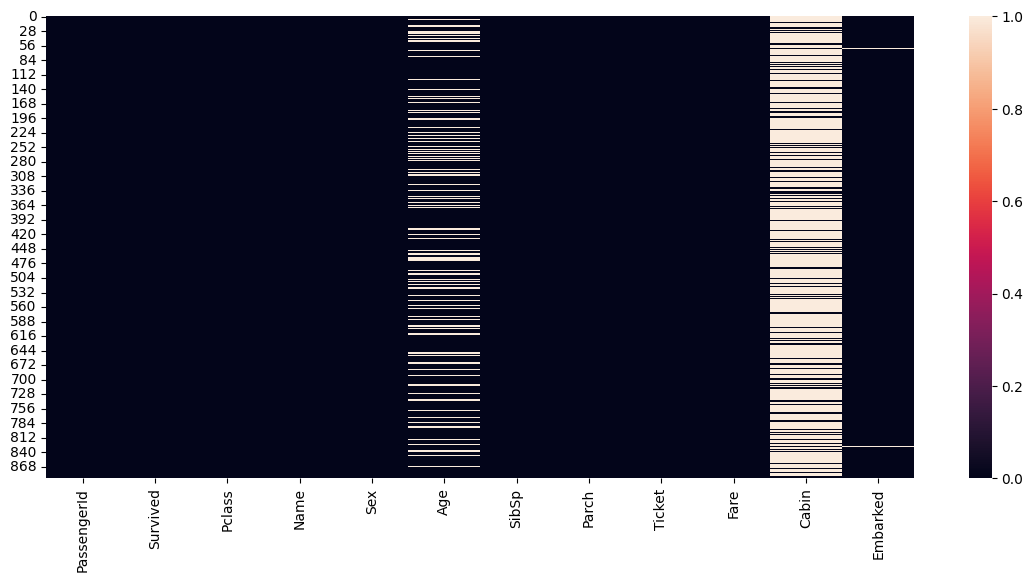

In [397]:
plt.figure(figsize=(14,6))
sns.heatmap(df.isna())
plt.show()

## preprocessing

In [398]:
df['Age']=df['Age'].fillna(df['Age'].mean())
df.drop(['Cabin','Name','PassengerId','Ticket'],axis=1,inplace=True)
df['Embarked'].dropna(inplace=True)

In [399]:
lab = LabelEncoder()
df['Gender'] = lab.fit_transform(df['Sex'])
df['Embarked'] = lab.fit_transform(df['Embarked'])


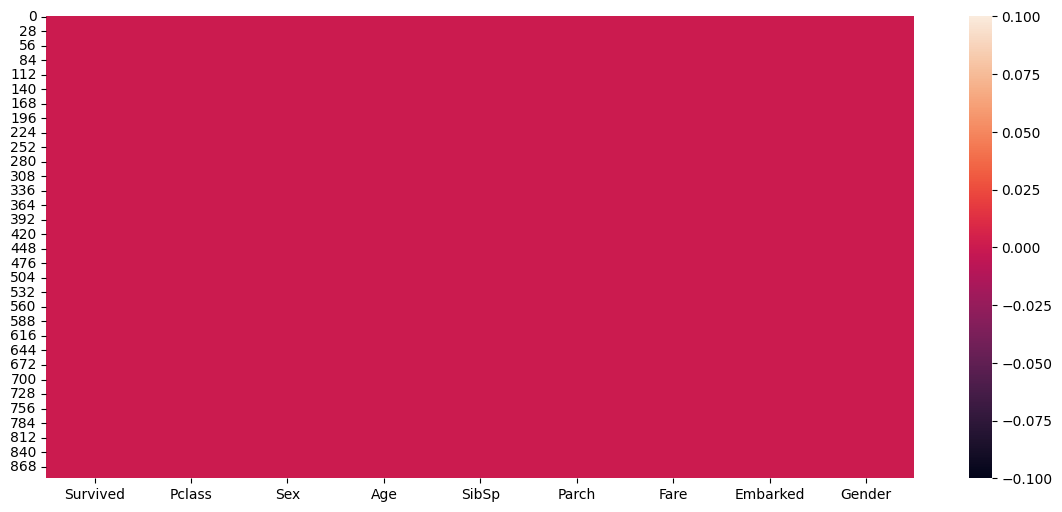

In [400]:
plt.figure(figsize=(14,6))
sns.heatmap(df.isna())
plt.show()

In [401]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
 8   Gender    891 non-null    int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 62.8+ KB


## Data analysis and visualizatioin (EDA)

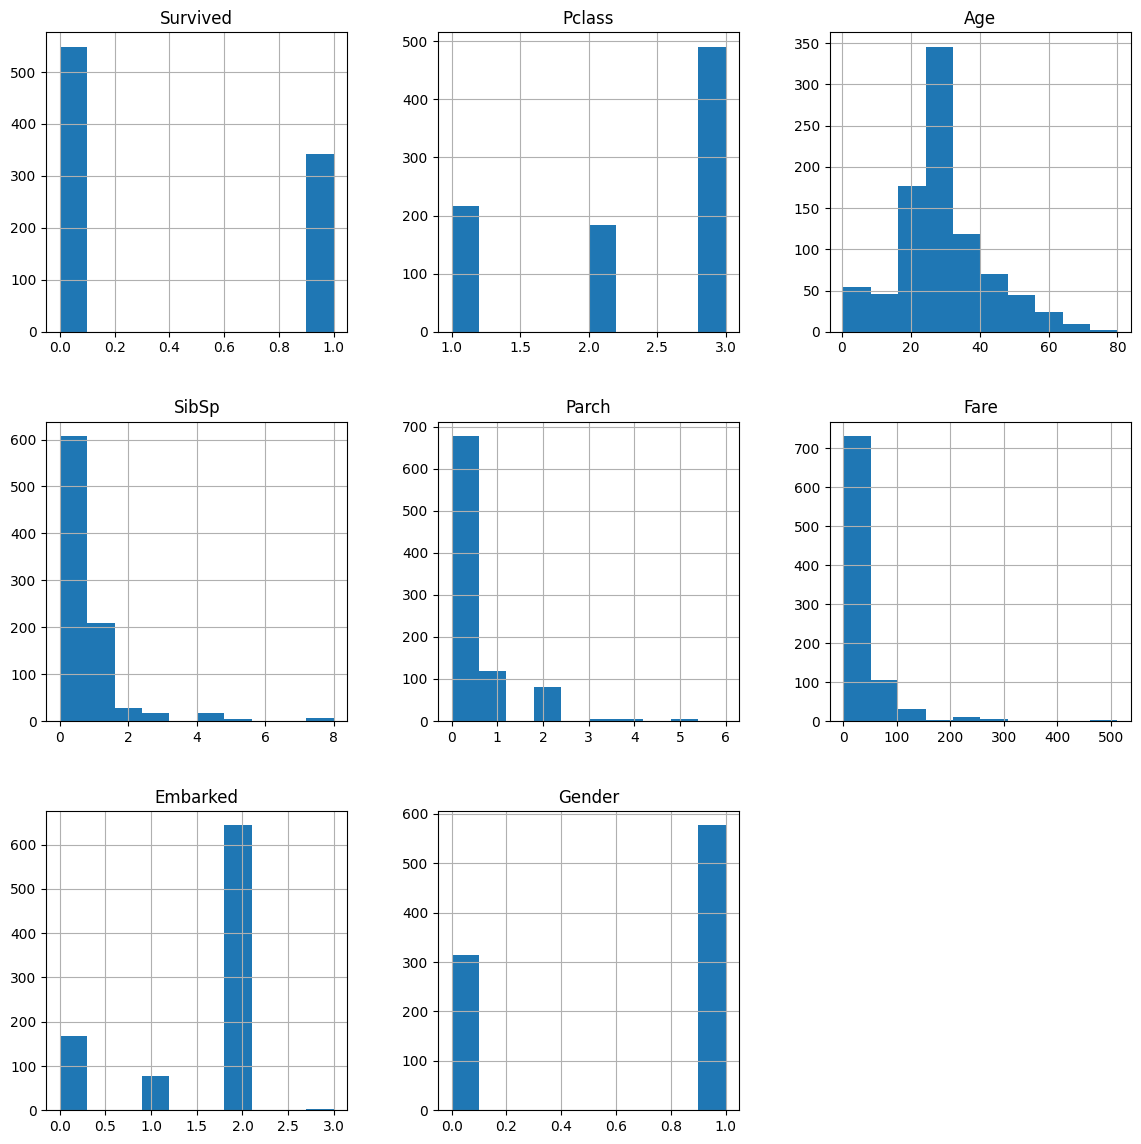

In [402]:

df.hist(figsize=(14,14))
plt.show()

<Axes: >

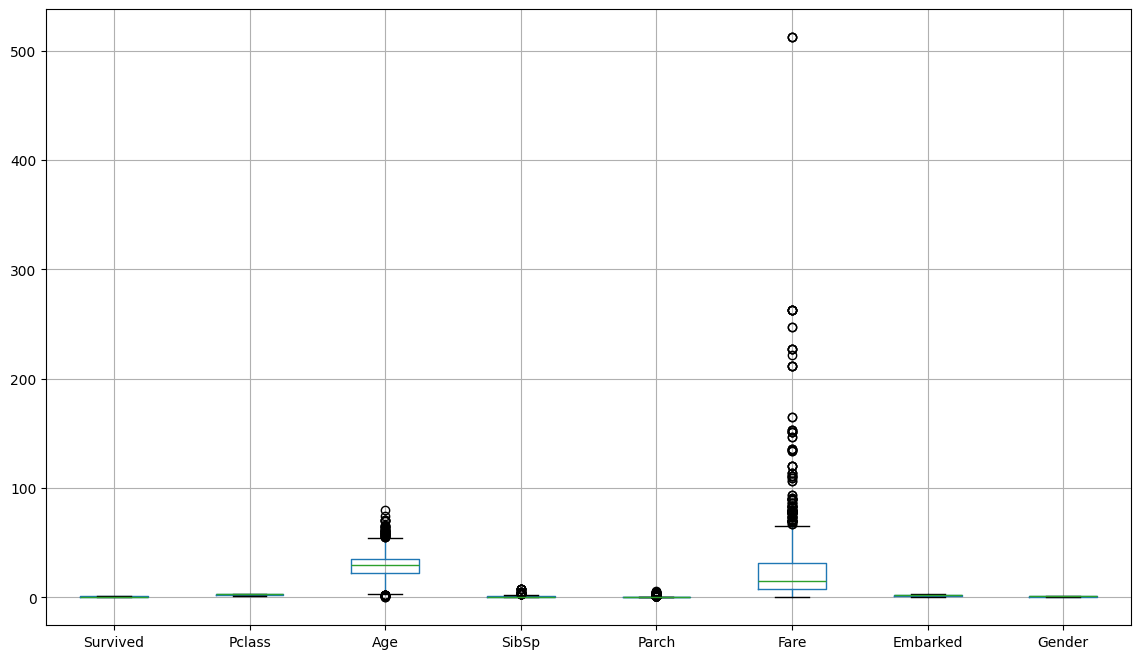

In [403]:
df.boxplot(figsize=(14,8))

<Axes: >

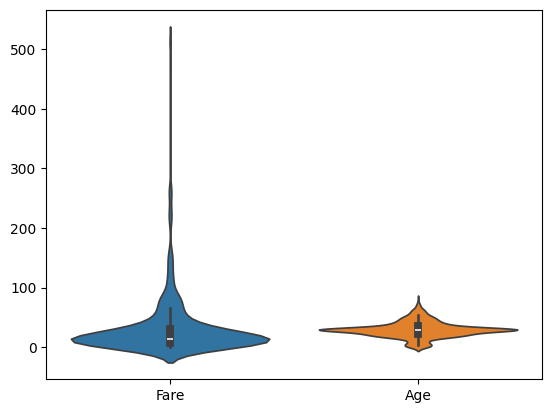

In [404]:
sns.violinplot(df[['Fare','Age']])

<Axes: >

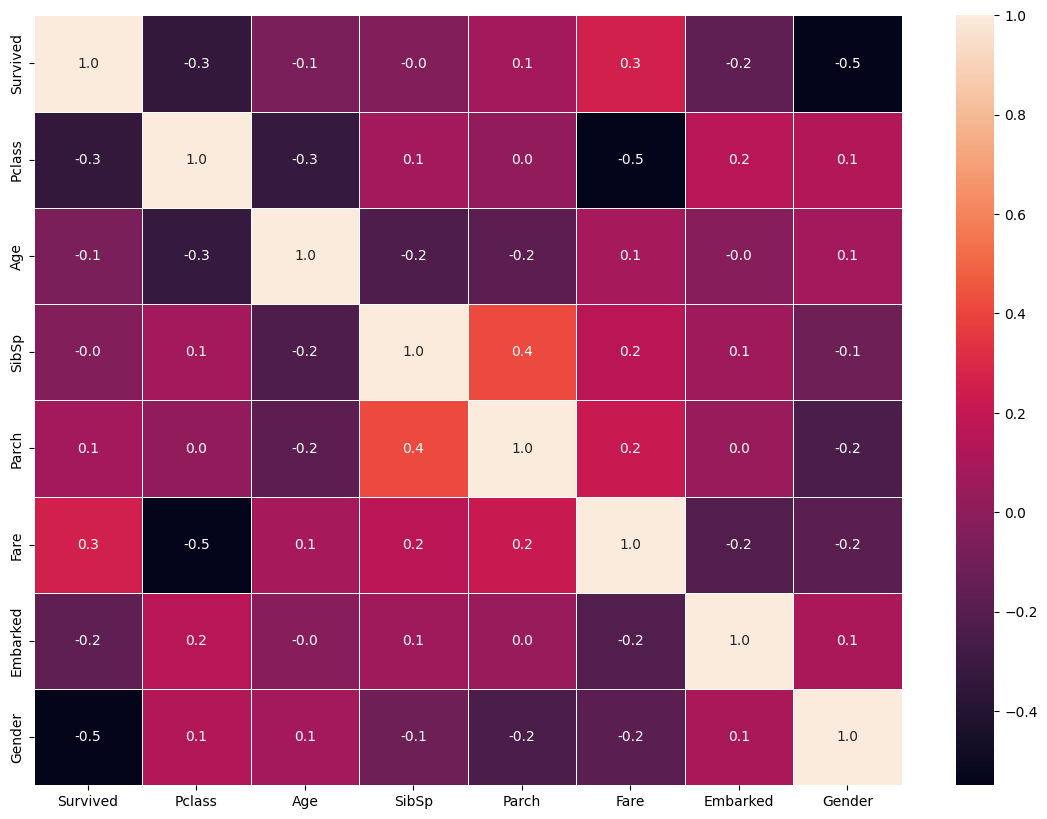

In [405]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt='.1f',linewidths=0.5)

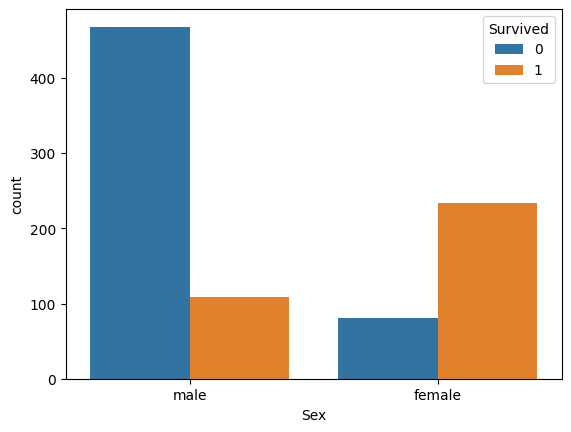

In [406]:
sns.countplot(data=df , x='Sex', hue='Survived')

plt.show()

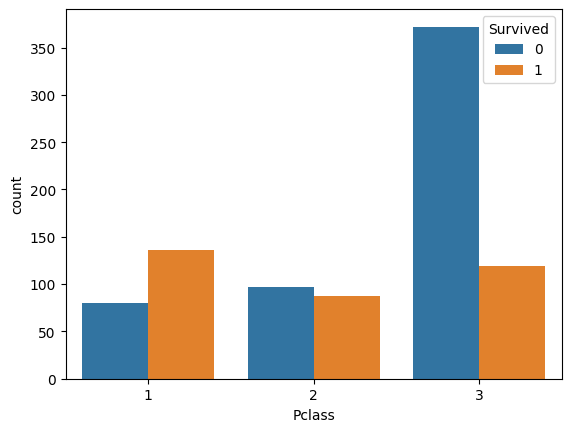

In [407]:
sns.countplot(data=df , x='Pclass', hue='Survived')
plt.show()

## buliding model

In [408]:
x = df.drop(['Survived','Sex'],axis=1)
y = df['Survived']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,shuffle=True,random_state=21)

In [409]:
scl = StandardScaler()
x_train = scl.fit_transform(x_train)
x_test = scl.transform(x_test)

In [410]:
accuracies = []

In [ ]:
def evaluate_model(model):
    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    accuracies.append(accuracy_score(y_test, pred))
    
    print("Model Score:", round(model.score(x_test, y_test),3))
    print("Accuracy:", round(accuracy_score(y_test, pred),3))
    
    print("\nClassification Report:")
    print(classification_report(y_test, pred))
    
    sns.heatmap(
        confusion_matrix(y_test, pred),
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [412]:
model1 = SVC()

model2 = GradientBoostingClassifier()

model3 = RandomForestClassifier()

model4 = DecisionTreeClassifier()

model5 = XGBClassifier()

model6 = LogisticRegression()

model7 = GaussianNB()

model8 = KNeighborsClassifier()

## evaluation models

Model Score: 0.812
Accuracy: 0.812

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.92      0.85       133
           1       0.84      0.66      0.74        90

    accuracy                           0.81       223
   macro avg       0.82      0.79      0.80       223
weighted avg       0.82      0.81      0.81       223



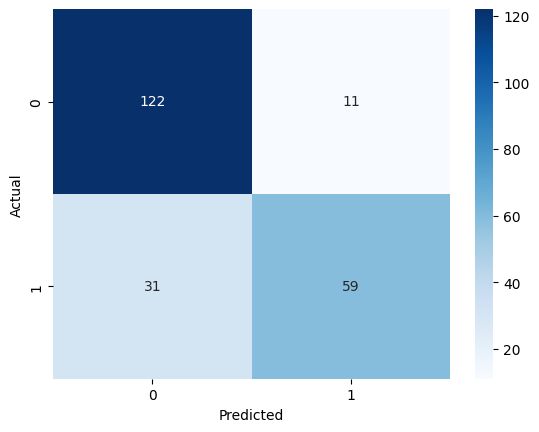

In [413]:
evaluate_model(model1)

Model Score: 0.834
Accuracy: 0.834

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.87       133
           1       0.84      0.73      0.78        90

    accuracy                           0.83       223
   macro avg       0.83      0.82      0.82       223
weighted avg       0.83      0.83      0.83       223



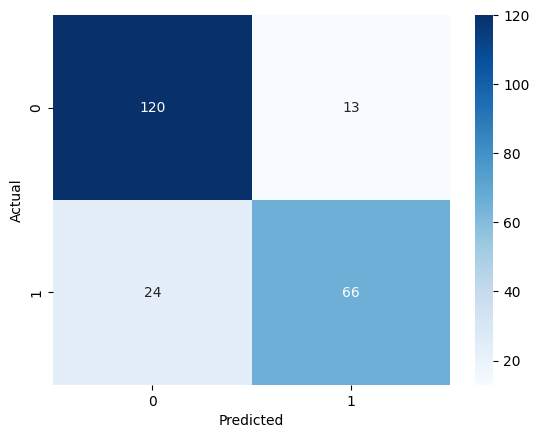

In [414]:
evaluate_model(model2)

Model Score: 0.812
Accuracy: 0.812

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       133
           1       0.78      0.74      0.76        90

    accuracy                           0.81       223
   macro avg       0.81      0.80      0.80       223
weighted avg       0.81      0.81      0.81       223



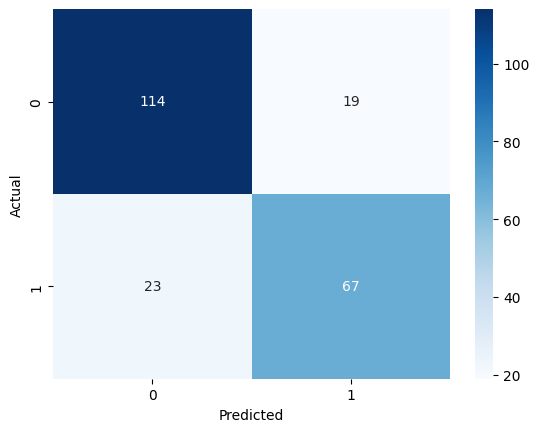

In [415]:
evaluate_model(model3)

Model Score: 0.78
Accuracy: 0.78

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       133
           1       0.74      0.71      0.72        90

    accuracy                           0.78       223
   macro avg       0.77      0.77      0.77       223
weighted avg       0.78      0.78      0.78       223



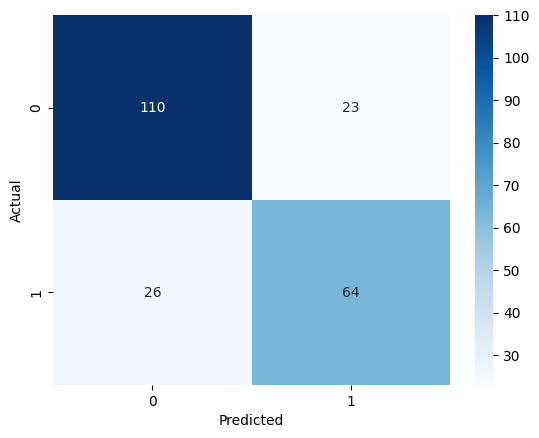

In [416]:
evaluate_model(model4)

Model Score: 0.848
Accuracy: 0.848

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88       133
           1       0.86      0.74      0.80        90

    accuracy                           0.85       223
   macro avg       0.85      0.83      0.84       223
weighted avg       0.85      0.85      0.85       223



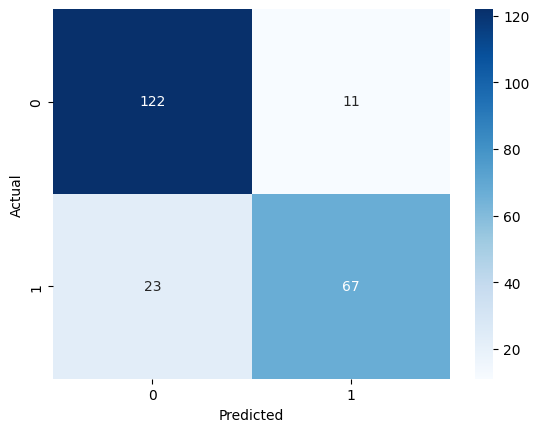

In [417]:
evaluate_model(model5)

Model Score: 0.798
Accuracy: 0.798

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.86      0.84       133
           1       0.77      0.71      0.74        90

    accuracy                           0.80       223
   macro avg       0.79      0.78      0.79       223
weighted avg       0.80      0.80      0.80       223



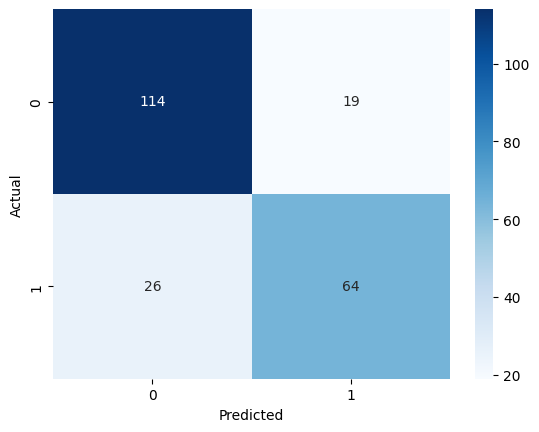

In [418]:
evaluate_model(model6)

Model Score: 0.807
Accuracy: 0.807

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       133
           1       0.77      0.74      0.76        90

    accuracy                           0.81       223
   macro avg       0.80      0.80      0.80       223
weighted avg       0.81      0.81      0.81       223



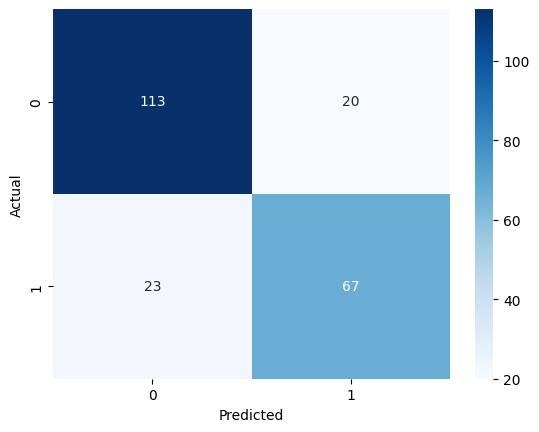

In [419]:
evaluate_model(model7)

Model Score: 0.794
Accuracy: 0.794

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       133
           1       0.78      0.69      0.73        90

    accuracy                           0.79       223
   macro avg       0.79      0.78      0.78       223
weighted avg       0.79      0.79      0.79       223



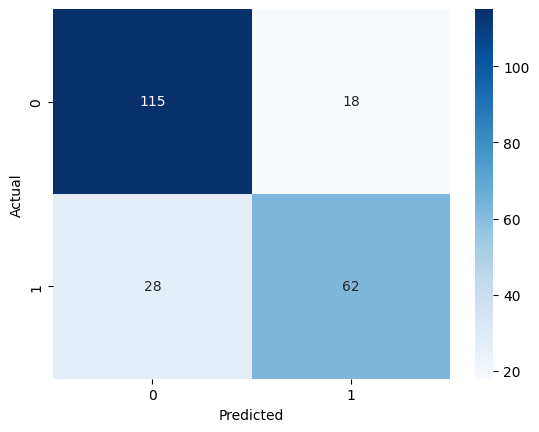

In [420]:
evaluate_model(model8)

In [421]:
Alghorisms= [ 'SVC', 'GradientBoostingClassifier', 'RandomForestClassifier', 'DecisionTreeClassifier', 'XGBClassifier', 'LogisticRegression', 'GaussianNB', 'KNeighborsClassifier' ]

In [422]:
df_models = pd.DataFrame({'Alghorisms':Alghorisms,'accuracies':accuracies})
df_models

,Alghorisms,accuracies
0,SVC,0.811659
1,GradientBoostingClassifier,0.834081
2,RandomForestClassifier,0.811659
3,DecisionTreeClassifier,0.780269
4,XGBClassifier,0.847534
5,LogisticRegression,0.798206
6,GaussianNB,0.807175
7,KNeighborsClassifier,0.793722


In [429]:
df_models.loc[df_models['accuracies'].idxmax()]

Alghorisms    XGBClassifier
accuracies         0.847534
Name: 4, dtype: object

In [432]:
df_models.sort_values('accuracies',ascending=False)

,Alghorisms,accuracies
4,XGBClassifier,0.847534
1,GradientBoostingClassifier,0.834081
2,RandomForestClassifier,0.811659
0,SVC,0.811659
6,GaussianNB,0.807175
5,LogisticRegression,0.798206
7,KNeighborsClassifier,0.793722
3,DecisionTreeClassifier,0.780269
